# 04 - RUL Regression


In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np
import matplotlib.pyplot as plt


## Train Regressor


In [3]:
df = pd.read_csv('../data/processed.csv')
X = df.drop(columns=['Machine failure', 'RUL', 'UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'], errors='ignore')
y = df['RUL']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred = rf.predict(X_test)


## Evaluation


In [5]:
print('MAE:', mean_absolute_error(y_test, y_pred))
print('RMSE:', np.sqrt(mean_squared_error(y_test, y_pred)))


MAE: 0.003890000000000015
RMSE: 0.07779652948557543


## Predicted vs Actual Plot


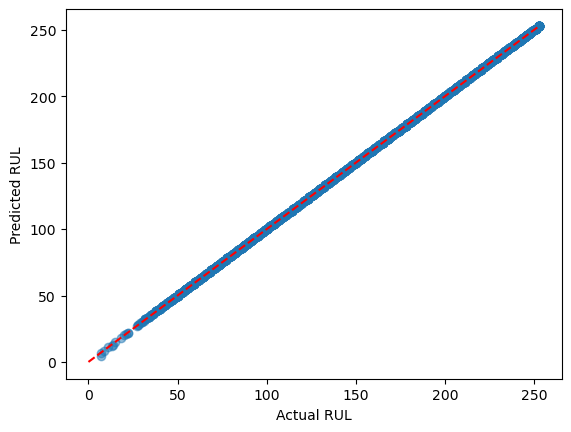

In [7]:
plt.scatter(y_test, y_pred, alpha=0.5)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.xlabel('Actual RUL')
plt.ylabel('Predicted RUL')
plt.show()
